# 04 — Signal Development & Validation

Validates the `MomentumSignal` module and inspects signal output.

**EDA findings baked in:**
- Primary lookback: **8h** (Sharpe 1.94, best L/S spread)
- Secondary blend: **4h** (30% weight)
- Universe avg AC(1) = -0.007 → near-zero, cross-sectional approach correct
- Position sizing: **inverse-ATR volatility weighted**
- Max 10 positions, max 25% per coin

In [11]:
import sys
sys.path.insert(0, '..')   # allow imports from project root

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone, timedelta

from signals.momentum import MomentumSignal, MomentumConfig, SignalDiagnostics, load_universe_from_csv

DB_PATH = '../data/ohlcv_1m.duckdb'
con = duckdb.connect(DB_PATH, read_only=True)

# Load universe saved by EDA notebook
universe = load_universe_from_csv('../data/tradeable_universe.csv')
print(f'Universe: {len(universe)} coins')

Universe: 58 coins


## 1. Instantiate Signal & Inspect Latest Output

In [12]:
# ── Cell 1: Instantiate Signal & Inspect Latest Output ──────────────────────
cfg = MomentumConfig()  # use all defaults from the updated config

signal = MomentumSignal(con=con, universe=universe, cfg=cfg)
diag   = SignalDiagnostics(signal)

# Use latest available timestamp in DB
latest_ts = con.execute("""
    SELECT MAX(ts) FROM ohlcv WHERE interval = '1m'
""").fetchone()[0]
latest_ts = pd.to_datetime(latest_ts, utc=True).replace(minute=0, second=0, microsecond=0)
print(f'Computing signal as of : {latest_ts}')
print(f'Lookback primary       : {cfg.lookback_primary}h')
print(f'Lookback secondary     : {cfg.lookback_secondary}h')
print(f'Min score threshold    : {cfg.min_score_threshold}')
print(f'Rebalance freq         : every {cfg.rebalance_freq_h}h')
print(f'Min turnover to trade  : {cfg.min_turnover_to_trade*100:.0f}%')

score_table = diag.score_table(latest_ts)
print(f'\nScore table shape  : {score_table.shape}')
print(f'Columns            : {list(score_table.columns)}')

mom_col_p = f'mom_{cfg.lookback_primary}h'
mom_col_s = f'mom_{cfg.lookback_secondary}h'

display(score_table[[mom_col_p, mom_col_s, 'score', 'rank',
                      'score_pass', 'abs_mom_pass', 'both_pass',
                      'atr_pct_14h', 'weight', 'selected']]
        .style
        .background_gradient(subset=['score'], cmap='RdYlGn')
        .background_gradient(subset=['weight'], cmap='Blues')
        .format({mom_col_p: '{:.4f}', mom_col_s: '{:.4f}',
                 'score': '{:.4f}', 'atr_pct_14h': '{:.3f}%',
                 'weight': '{:.4f}'}))

Computing signal as of : 2026-03-18 07:00:00+00:00
Lookback primary       : 6h
Lookback secondary     : 3h
Min score threshold    : 0.6
Rebalance freq         : every 4h
Min turnover to trade  : 5%



Score table shape  : (58, 10)
Columns            : ['mom_6h', 'mom_3h', 'score', 'rank', 'score_pass', 'abs_mom_pass', 'both_pass', 'selected', 'atr_pct_14h', 'weight']


,mom_6h,mom_3h,score,rank,score_pass,abs_mom_pass,both_pass,atr_pct_14h,weight,selected
XPL-USD,0.0703,0.0512,1.0000,1,True,True,True,2.174%,0.0789,True
FET-USD,0.0414,0.0233,0.9776,2,True,True,True,2.615%,0.0656,True
WIF-USD,0.0267,0.0213,0.9603,3,True,True,True,1.729%,0.0992,True
BONK-USD,0.0243,0.0243,0.9586,4,True,True,True,1.480%,0.1159,True
DOT-USD,0.0218,0.0193,0.9103,5,True,True,True,0.858%,0.2001,True
PENGU-USD,0.0210,0.0206,0.9069,6,True,True,True,1.385%,0.1239,True
APT-USD,0.0189,0.0199,0.8776,7,True,True,True,1.001%,0.1714,True
CFX-USD,0.0214,0.0142,0.8724,8,True,True,True,1.184%,0.1449,True
ENA-USD,0.0188,0.0188,0.8448,9,True,True,True,1.099%,0.0000,False
PUMP-USD,0.0182,0.0143,0.8224,10,True,True,True,1.441%,0.0000,False


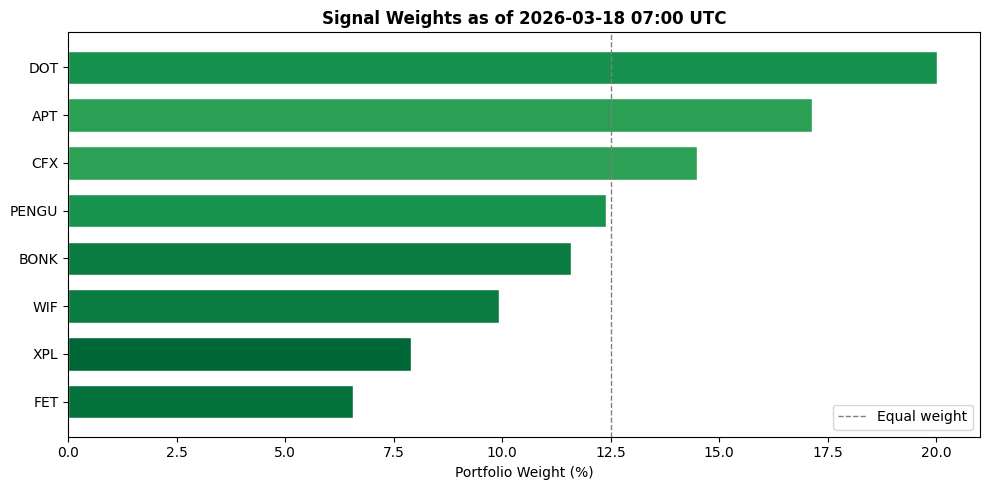


Total allocated: 100.0%
Cash buffer    : -0.0%


In [13]:
# Portfolio weight bar chart
selected = score_table[score_table['selected'] & (score_table['weight'] > 0)].copy()
selected = selected.sort_values('weight', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.RdYlGn(selected['score'].values)
bars = ax.barh(selected.index.str.replace('-USD',''), selected['weight'] * 100,
               color=colors, edgecolor='white', height=0.7)
ax.set_xlabel('Portfolio Weight (%)')
ax.set_title(f'Signal Weights as of {latest_ts.strftime("%Y-%m-%d %H:%M UTC")}', fontweight='bold')
ax.axvline(100/len(selected), color='gray', linestyle='--', linewidth=1, label='Equal weight')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nTotal allocated: {selected["weight"].sum()*100:.1f}%')
print(f'Cash buffer    : {(1 - selected["weight"].sum())*100:.1f}%')

## 2. Walk-Forward Signal Validation

Replay signal across all historical hourly timestamps.
Check:
- Weight stability (turnover per rebalance)
- Signal concentration over time
- How often min_n threshold is not met

In [14]:
# Generate hourly timestamps over the data window
first_ts = con.execute("SELECT MIN(ts) FROM ohlcv WHERE interval = '1m'").fetchone()[0]
first_ts = pd.to_datetime(first_ts, utc=True).replace(minute=0, second=0, microsecond=0)

# Start after enough warmup (need at least lookback_primary + vol_lookback hours)
warmup_h = cfg.lookback_primary + cfg.vol_lookback + 5
start_ts = first_ts + timedelta(hours=warmup_h)

timestamps = pd.date_range(start=start_ts, end=latest_ts, freq='1h', tz='UTC').tolist()
print(f'Replaying signal over {len(timestamps)} hourly timestamps...')
print(f'From: {timestamps[0]}  →  {timestamps[-1]}')

Replaying signal over 696 hourly timestamps...
From: 2026-02-17 08:00:00+00:00  →  2026-03-18 07:00:00+00:00


In [15]:
# Batch compute — this may take 1-3 minutes depending on data size
weights_df = signal.compute_batch(timestamps)
print(f'Weight matrix shape: {weights_df.shape}')
print(f'Non-zero positions per row: {(weights_df > 0).sum(axis=1).describe().round(2)}')

Only 2 liquid coins in top-8 after vol filter — skipping rebalance
Only 2 liquid coins in top-8 after vol filter — skipping rebalance
Only 2 liquid coins in top-8 after vol filter — skipping rebalance
Only 2 liquid coins in top-8 after vol filter — skipping rebalance


Weight matrix shape: (696, 58)
Non-zero positions per row: count    696.00
mean       6.95
std        1.51
min        3.00
25%        6.00
50%        8.00
75%        8.00
max        8.00
dtype: float64


Turnover per rebalance (1h):
  Mean   : 17.96%
  Median : 0.00%
  95th % : 90.99%

Estimated fee per rebalance (0.10% taker × turnover):
  Mean   : 0.0180%
  Daily  : 0.431% (24 rebalances/day)


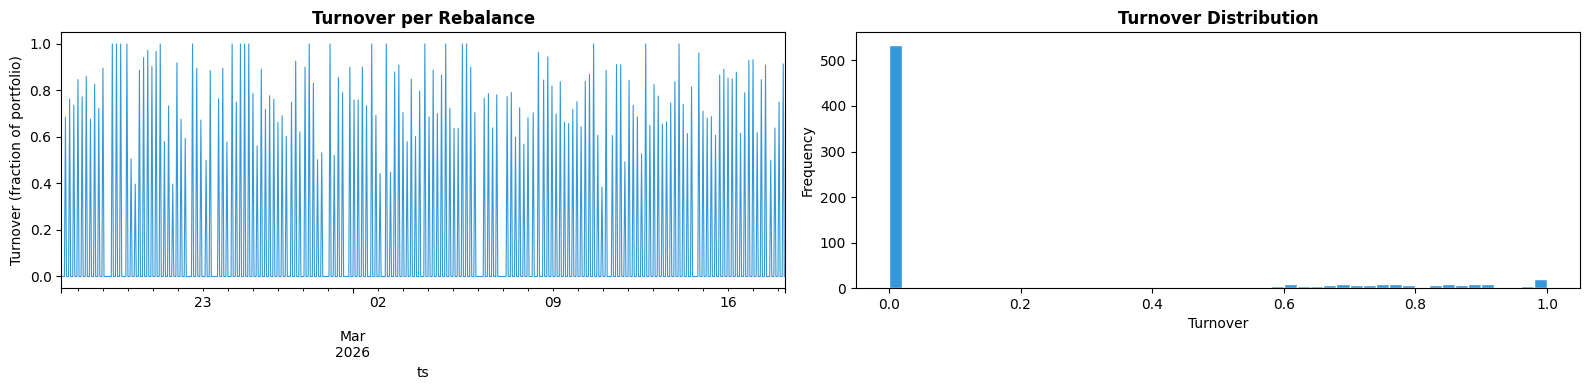

In [16]:
# Turnover analysis
# Turnover = sum(|w_t - w_{t-1}|) / 2 per rebalance
turnover = weights_df.diff().abs().sum(axis=1) / 2
turnover = turnover.dropna()

print(f'Turnover per rebalance (1h):')
print(f'  Mean   : {turnover.mean()*100:.2f}%')
print(f'  Median : {turnover.median()*100:.2f}%')
print(f'  95th % : {turnover.quantile(0.95)*100:.2f}%')
print()
print(f'Estimated fee per rebalance (0.10% taker × turnover):')
print(f'  Mean   : {turnover.mean() * 0.001 * 100:.4f}%')
print(f'  Daily  : {turnover.mean() * 0.001 * 24 * 100:.3f}% (24 rebalances/day)')

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
turnover.plot(ax=axes[0], color='#3498db', linewidth=0.8)
axes[0].set_title('Turnover per Rebalance', fontweight='bold')
axes[0].set_ylabel('Turnover (fraction of portfolio)')
turnover.plot.hist(bins=50, ax=axes[1], color='#3498db', edgecolor='white')
axes[1].set_title('Turnover Distribution', fontweight='bold')
axes[1].set_xlabel('Turnover')
plt.tight_layout()
plt.show()

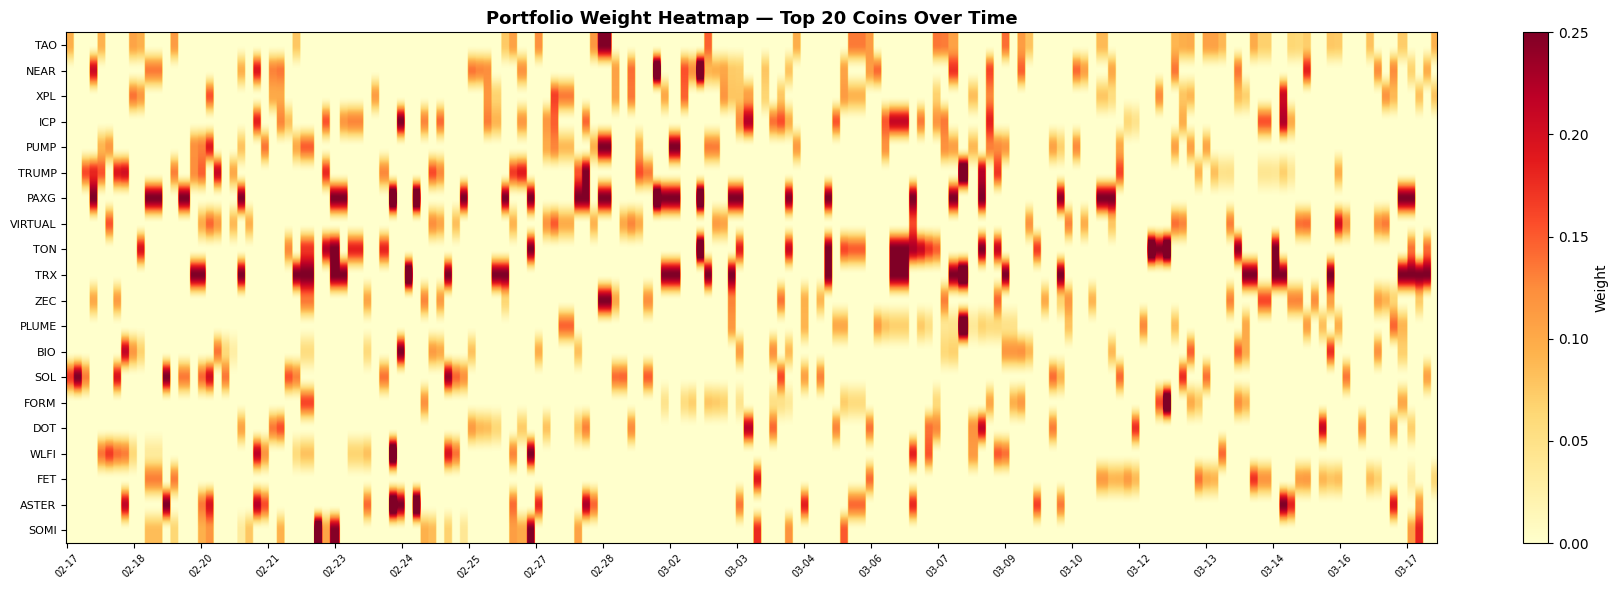


Selection frequency (% of hours in portfolio):
TAO-USD        23.9
NEAR-USD       23.4
XPL-USD        23.1
ICP-USD        21.3
PUMP-USD       21.0
TRUMP-USD      20.0
PAXG-USD       19.7
VIRTUAL-USD    19.5
TON-USD        19.5
TRX-USD        19.5
ZEC-USD        18.7
PLUME-USD      18.1
BIO-USD        18.0
SOL-USD        16.7
FORM-USD       15.7
DOT-USD        15.5
WLFI-USD       15.1
FET-USD        14.5
ASTER-USD      14.5
SOMI-USD       14.2


In [17]:
# Weight stability heatmap — which coins are selected over time?
# Show top 20 most-selected coins
selection_freq = (weights_df > 0).mean().sort_values(ascending=False)
top20 = selection_freq.head(20).index.tolist()

fig, ax = plt.subplots(figsize=(18, 6))
heat_data = weights_df[top20].T
im = ax.imshow(heat_data.values, aspect='auto', cmap='YlOrRd',
               vmin=0, vmax=cfg.max_weight)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([s.replace('-USD','') for s in top20], fontsize=8)
# Only show every 24th timestamp on x-axis
step = max(1, len(heat_data.columns) // 20)
ax.set_xticks(range(0, len(heat_data.columns), step))
ax.set_xticklabels(
    [heat_data.columns[i].strftime('%m-%d') for i in range(0, len(heat_data.columns), step)],
    rotation=45, fontsize=7
)
plt.colorbar(im, ax=ax, label='Weight')
ax.set_title('Portfolio Weight Heatmap — Top 20 Coins Over Time', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/signal_weight_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSelection frequency (% of hours in portfolio):')
print(selection_freq.head(20).mul(100).round(1).to_string())

In [18]:
# ── Cell 1: Instantiate Signal & Inspect Latest Output ──────────────────────
cfg = MomentumConfig()  # use all defaults from the updated config

signal = MomentumSignal(con=con, universe=universe, cfg=cfg)
diag   = SignalDiagnostics(signal)

# Use latest available timestamp in DB
latest_ts = con.execute("""
    SELECT MAX(ts) FROM ohlcv WHERE interval = '1m'
""").fetchone()[0]
latest_ts = pd.to_datetime(latest_ts, utc=True).replace(minute=0, second=0, microsecond=0)
print(f'Computing signal as of : {latest_ts}')
print(f'Lookback primary       : {cfg.lookback_primary}h')
print(f'Lookback secondary     : {cfg.lookback_secondary}h')
print(f'Min score threshold    : {cfg.min_score_threshold}')
print(f'Rebalance freq         : every {cfg.rebalance_freq_h}h')
print(f'Min turnover to trade  : {cfg.min_turnover_to_trade*100:.0f}%')

score_table = diag.score_table(latest_ts)
print(f'\nScore table shape  : {score_table.shape}')
print(f'Columns            : {list(score_table.columns)}')

mom_col_p = f'mom_{cfg.lookback_primary}h'
mom_col_s = f'mom_{cfg.lookback_secondary}h'

display(score_table[[mom_col_p, mom_col_s, 'score', 'rank',
                      'score_pass', 'abs_mom_pass', 'both_pass',
                      'atr_pct_14h', 'weight', 'selected']]
        .style
        .background_gradient(subset=['score'], cmap='RdYlGn')
        .background_gradient(subset=['weight'], cmap='Blues')
        .format({mom_col_p: '{:.4f}', mom_col_s: '{:.4f}',
                 'score': '{:.4f}', 'atr_pct_14h': '{:.3f}%',
                 'weight': '{:.4f}'}))

Computing signal as of : 2026-03-18 07:00:00+00:00
Lookback primary       : 6h
Lookback secondary     : 3h
Min score threshold    : 0.6
Rebalance freq         : every 4h
Min turnover to trade  : 5%

Score table shape  : (58, 10)
Columns            : ['mom_6h', 'mom_3h', 'score', 'rank', 'score_pass', 'abs_mom_pass', 'both_pass', 'selected', 'atr_pct_14h', 'weight']


,mom_6h,mom_3h,score,rank,score_pass,abs_mom_pass,both_pass,atr_pct_14h,weight,selected
XPL-USD,0.0703,0.0512,1.0000,1,True,True,True,2.174%,0.0789,True
FET-USD,0.0414,0.0233,0.9776,2,True,True,True,2.615%,0.0656,True
WIF-USD,0.0267,0.0213,0.9603,3,True,True,True,1.729%,0.0992,True
BONK-USD,0.0243,0.0243,0.9586,4,True,True,True,1.480%,0.1159,True
DOT-USD,0.0218,0.0193,0.9103,5,True,True,True,0.858%,0.2001,True
PENGU-USD,0.0210,0.0206,0.9069,6,True,True,True,1.385%,0.1239,True
APT-USD,0.0189,0.0199,0.8776,7,True,True,True,1.001%,0.1714,True
CFX-USD,0.0214,0.0142,0.8724,8,True,True,True,1.184%,0.1449,True
ENA-USD,0.0188,0.0188,0.8448,9,True,True,True,1.099%,0.0000,False
PUMP-USD,0.0182,0.0143,0.8224,10,True,True,True,1.441%,0.0000,False


## 3. Signal Sensitivity Analysis

Test how signal quality changes across different lookback windows.
Confirm 8h is robust and not just a lucky parameter.

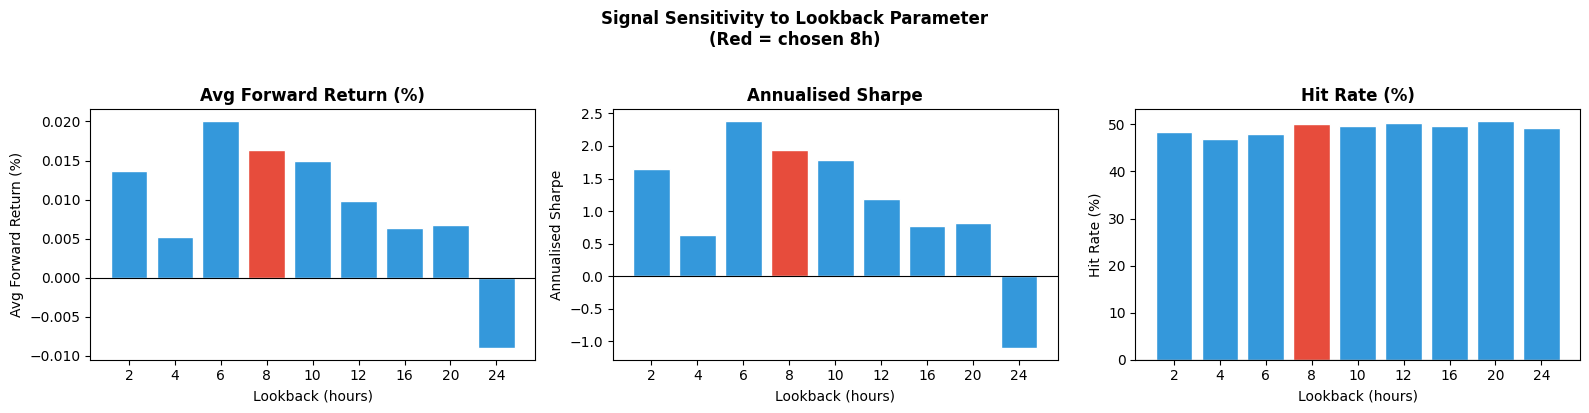

 lookback_h  mean_fwd_ret  sharpe  hit_rate
          2        0.0136  1.6491   48.4680
          4        0.0053  0.6275   46.9274
          6        0.0201  2.3910   47.8992
          8        0.0163  1.9398   50.1404
         10        0.0150  1.7802   49.5775
         12        0.0098  1.1888   50.2825
         16        0.0064  0.7767   49.7159
         20        0.0068  0.8248   50.7143
         24       -0.0090 -1.1063   49.2816


In [19]:
# Quick sensitivity: vary lookback_primary from 4 to 24h
# Measure: avg top-quintile forward return (proxy for signal quality)

pivot_close = con.execute("""
    SELECT DATE_TRUNC('hour', ts) AS ts_hour, symbol,
           LAST(close ORDER BY ts) AS close
    FROM ohlcv
    WHERE interval = '1m'
    GROUP BY DATE_TRUNC('hour', ts), symbol
    ORDER BY ts_hour
""").df()

pivot_close['ts_hour'] = pd.to_datetime(pivot_close['ts_hour'], utc=True)
pivot = pivot_close[pivot_close['symbol'].isin(universe)].pivot_table(
    index='ts_hour', columns='symbol', values='close'
).sort_index()

sensitivity_results = []
for lb in [2, 4, 6, 8, 10, 12, 16, 20, 24]:
    mom  = pivot.pct_change(lb)
    fwd  = pivot.pct_change(1).shift(-1)
    rnk  = mom.rank(axis=1, pct=True)
    top  = fwd.where(rnk >= 0.8).mean(axis=1).dropna()
    sensitivity_results.append({
        'lookback_h'   : lb,
        'mean_fwd_ret' : top.mean() * 100,
        'sharpe'       : top.mean() / top.std() * np.sqrt(24 * 365) if top.std() > 0 else 0,
        'hit_rate'     : (top > 0).mean() * 100,
    })

sens_df = pd.DataFrame(sensitivity_results)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, (col, label) in enumerate([('mean_fwd_ret','Avg Forward Return (%)'),
                                    ('sharpe','Annualised Sharpe'),
                                    ('hit_rate','Hit Rate (%)')]):
    colors = ['#e74c3c' if lb == 8 else '#3498db' for lb in sens_df['lookback_h']]
    axes[i].bar(sens_df['lookback_h'].astype(str), sens_df[col], color=colors, edgecolor='white')
    axes[i].set_xlabel('Lookback (hours)')
    axes[i].set_ylabel(label)
    axes[i].set_title(label, fontweight='bold')
    axes[i].axhline(0, color='black', linewidth=0.8)

plt.suptitle('Signal Sensitivity to Lookback Parameter\n(Red = chosen 8h)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/signal_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print(sens_df.round(4).to_string(index=False))

In [20]:
con.close()
print('Done. Next: research/05_backtest.ipynb')

Done. Next: research/05_backtest.ipynb
